In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from trajectory_generation import TrajectoryCollector

In [2]:
collector = TrajectoryCollector()
dataset = collector.collect_multiple_trajectories(10000, 'mixed', 200)

Trajectory 1: 22 steps
Trajectory 2: 15 steps
Trajectory 3: 9 steps
Trajectory 4: 13 steps
Trajectory 5: 200 steps
Trajectory 6: 11 steps
Trajectory 7: 9 steps
Trajectory 8: 19 steps
Trajectory 9: 9 steps
Trajectory 10: 18 steps
Trajectory 11: 27 steps
Trajectory 12: 8 steps
Trajectory 13: 40 steps
Trajectory 14: 8 steps
Trajectory 15: 39 steps
Trajectory 16: 8 steps
Trajectory 17: 9 steps
Trajectory 18: 9 steps
Trajectory 19: 11 steps
Trajectory 20: 23 steps
Trajectory 21: 9 steps
Trajectory 22: 9 steps
Trajectory 23: 30 steps
Trajectory 24: 17 steps
Trajectory 25: 13 steps
Trajectory 26: 8 steps
Trajectory 27: 37 steps
Trajectory 28: 10 steps
Trajectory 29: 9 steps
Trajectory 30: 31 steps
Trajectory 31: 8 steps
Trajectory 32: 9 steps
Trajectory 33: 14 steps
Trajectory 34: 10 steps
Trajectory 35: 9 steps
Trajectory 36: 15 steps
Trajectory 37: 200 steps
Trajectory 38: 9 steps
Trajectory 39: 9 steps
Trajectory 40: 26 steps
Trajectory 41: 35 steps
Trajectory 42: 13 steps
Trajectory 43: 2

In [3]:
def trajectories_to_dataframe_fast(trajectories):

    all_data = []

    for traj_id, traj in enumerate(trajectories):

        obs = traj.get_observations()
        next_obs = traj.get_next_observations()
        actions = traj.get_actions()

        T = len(traj)

        traj_data = pd.DataFrame({

            # Metadata
            'trajectory_id': [traj_id] * T,
            'step': range(T),

            # Current state x_t
            'cart_pos': obs[:, 0],
            'cart_vel': obs[:, 1],
            'pole_angle': obs[:, 2],
            'pole_vel': obs[:, 3],

            # Action a_t
            'action': actions,

            # Next state x_{t+1}
            'next_cart_pos': next_obs[:, 0],
            'next_cart_vel': next_obs[:, 1],
            'next_pole_angle': next_obs[:, 2],
            'next_pole_vel': next_obs[:, 3],
        })

        all_data.append(traj_data)

    return pd.concat(all_data, ignore_index=True)
df = trajectories_to_dataframe_fast(dataset)

In [4]:
# Check trajectories with 200 steps
trajectory_lengths = df.groupby('trajectory_id').size()

# Display trajectories that reached 200 steps
max_steps_trajectories = trajectory_lengths[trajectory_lengths >= 40]

print(f"Total trajectories: {len(trajectory_lengths)}")
print(f"Trajectories with 40 steps: {len(max_steps_trajectories)}")
print(f"Trajectories with < 40 steps: {len(trajectory_lengths) - len(max_steps_trajectories)}")
print(f"\nTrajectory IDs with 40 steps: {max_steps_trajectories.index.tolist()}")


Total trajectories: 10000
Trajectories with 40 steps: 1432
Trajectories with < 40 steps: 8568

Trajectory IDs with 40 steps: [4, 12, 36, 46, 48, 57, 62, 69, 88, 89, 90, 92, 93, 98, 116, 121, 124, 125, 130, 131, 140, 141, 142, 148, 149, 158, 159, 174, 185, 187, 193, 198, 201, 204, 211, 212, 217, 223, 224, 225, 245, 255, 271, 281, 283, 286, 292, 295, 297, 298, 303, 310, 311, 314, 315, 329, 338, 339, 353, 357, 364, 401, 402, 415, 416, 442, 451, 458, 460, 474, 495, 497, 499, 500, 507, 521, 524, 527, 545, 546, 549, 551, 552, 557, 564, 575, 579, 580, 581, 582, 591, 592, 617, 623, 627, 628, 635, 636, 647, 651, 676, 699, 707, 709, 713, 714, 716, 717, 727, 744, 747, 748, 752, 754, 760, 769, 770, 775, 787, 794, 805, 820, 821, 834, 836, 839, 843, 853, 867, 870, 875, 884, 891, 895, 896, 907, 918, 933, 934, 942, 952, 958, 966, 972, 996, 1013, 1021, 1022, 1041, 1049, 1052, 1053, 1061, 1062, 1071, 1076, 1085, 1089, 1097, 1099, 1114, 1120, 1133, 1138, 1147, 1159, 1165, 1167, 1174, 1176, 1194, 1217, 12

In [5]:
# Check what you got
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nTrajectory IDs: {df['trajectory_id'].nunique()}")
print(f"Total steps: {len(df)}")

DataFrame shape: (340349, 11)
Columns: ['trajectory_id', 'step', 'cart_pos', 'cart_vel', 'pole_angle', 'pole_vel', 'action', 'next_cart_pos', 'next_cart_vel', 'next_pole_angle', 'next_pole_vel']

First 5 rows:
   trajectory_id  step  cart_pos  cart_vel  pole_angle  pole_vel  action  \
0              0     0 -0.040311  0.005425    0.001276 -0.013817       0   
1              0     1 -0.040202 -0.189715    0.001000  0.279268       1   
2              0     2 -0.043997  0.005393    0.006586 -0.013099       1   
3              0     3 -0.043889  0.200420    0.006324 -0.303697       0   
4              0     4 -0.039880  0.005208    0.000250 -0.009026       0   

   next_cart_pos  next_cart_vel  next_pole_angle  next_pole_vel  
0      -0.040202      -0.189715         0.001000       0.279268  
1      -0.043997       0.005393         0.006586      -0.013099  
2      -0.043889       0.200420         0.006324      -0.303697  
3      -0.039880       0.005208         0.000250      -0.009026  
4  

In [6]:
print("=== DATA INFO ===")
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nBasic stats:\n{df.describe()}")

=== DATA INFO ===
Shape: (340349, 11)

Missing values:
trajectory_id      0
step               0
cart_pos           0
cart_vel           0
pole_angle         0
pole_vel           0
action             0
next_cart_pos      0
next_cart_vel      0
next_pole_angle    0
next_pole_vel      0
dtype: int64

Data types:
trajectory_id        int64
step                 int64
cart_pos           float32
cart_vel           float32
pole_angle         float32
pole_vel           float32
action               int64
next_cart_pos      float32
next_cart_vel      float32
next_pole_angle    float32
next_pole_vel      float32
dtype: object

Basic stats:
       trajectory_id           step       cart_pos       cart_vel  \
count  340349.000000  340349.000000  340349.000000  340349.000000   
mean     5004.175943      62.883105       0.005354       0.004827   
std      2862.579394      62.417387       0.234585       0.451969   
min         0.000000       0.000000      -1.614168      -2.609404   
25%      2541.0000

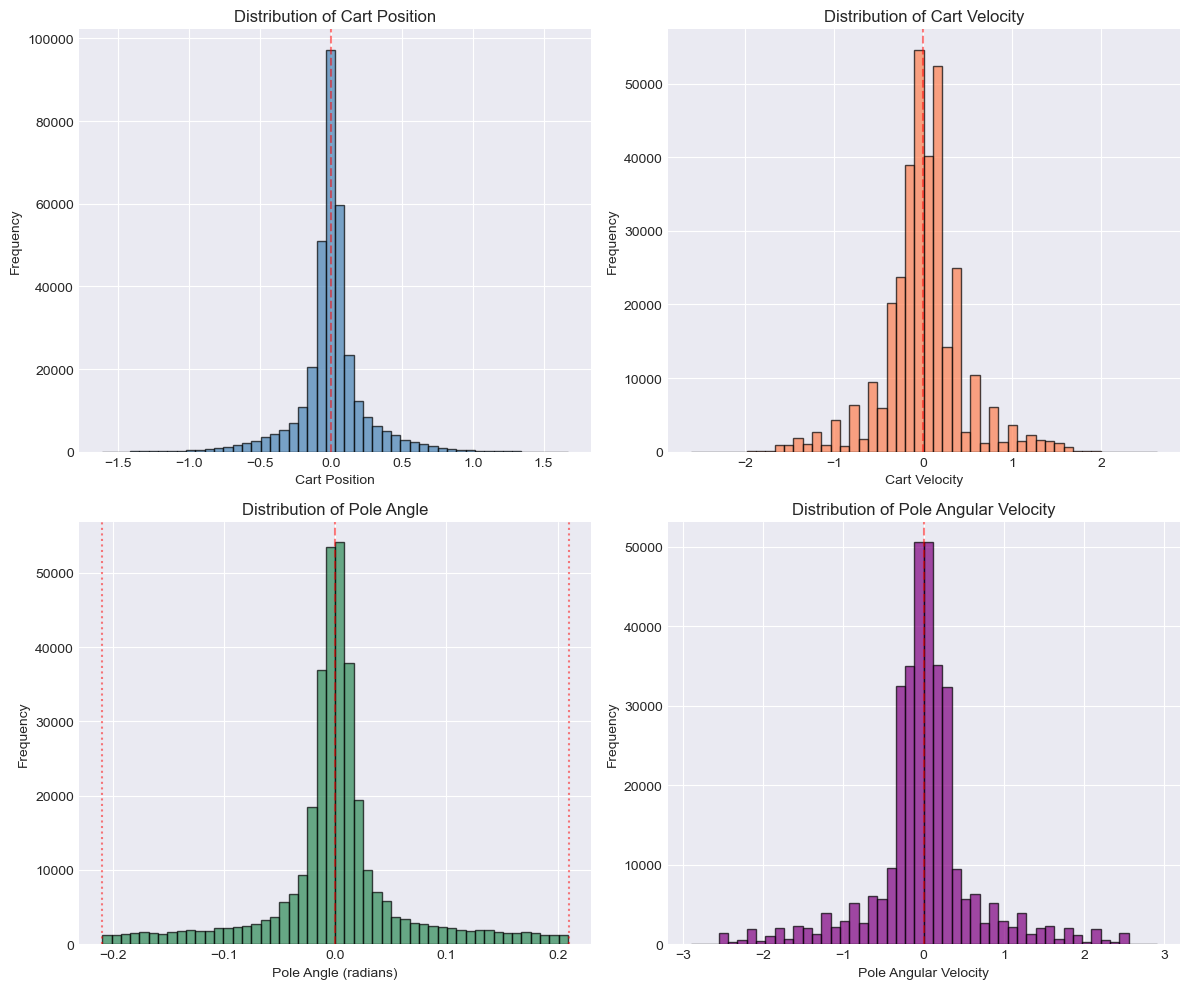

In [7]:
import seaborn as sns
# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Cart Position histogram
axes[0, 0].hist(df['cart_pos'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Cart Position')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Cart Position')
axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# 2. Cart Velocity histogram
axes[0, 1].hist(df['cart_vel'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Cart Velocity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Cart Velocity')
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# 3. Pole Angle histogram
axes[1, 0].hist(df['pole_angle'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Pole Angle (radians)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Pole Angle')
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
# Add threshold lines
axes[1, 0].axvline(x=0.21, color='red', linestyle=':', alpha=0.5, label='Fall threshold')
axes[1, 0].axvline(x=-0.21, color='red', linestyle=':', alpha=0.5)

# 4. Pole Angular Velocity histogram
axes[1, 1].hist(df['pole_vel'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Pole Angular Velocity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Pole Angular Velocity')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

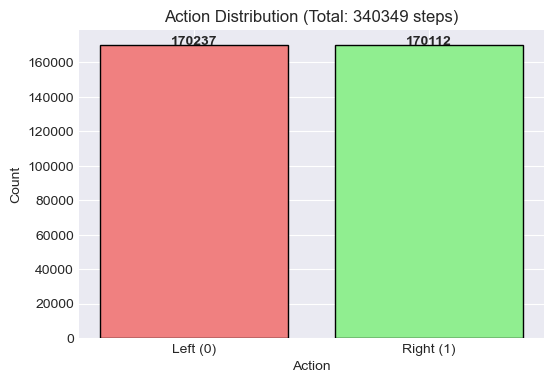

In [8]:
# Also show action distribution
plt.figure(figsize=(6, 4))
action_counts = df['action'].value_counts()
plt.bar(['Left (0)', 'Right (1)'], action_counts.values, color=['lightcoral', 'lightgreen'], edgecolor='black')
plt.xlabel('Action')
plt.ylabel('Count')
plt.title(f'Action Distribution (Total: {len(df)} steps)')
for i, v in enumerate(action_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.show()

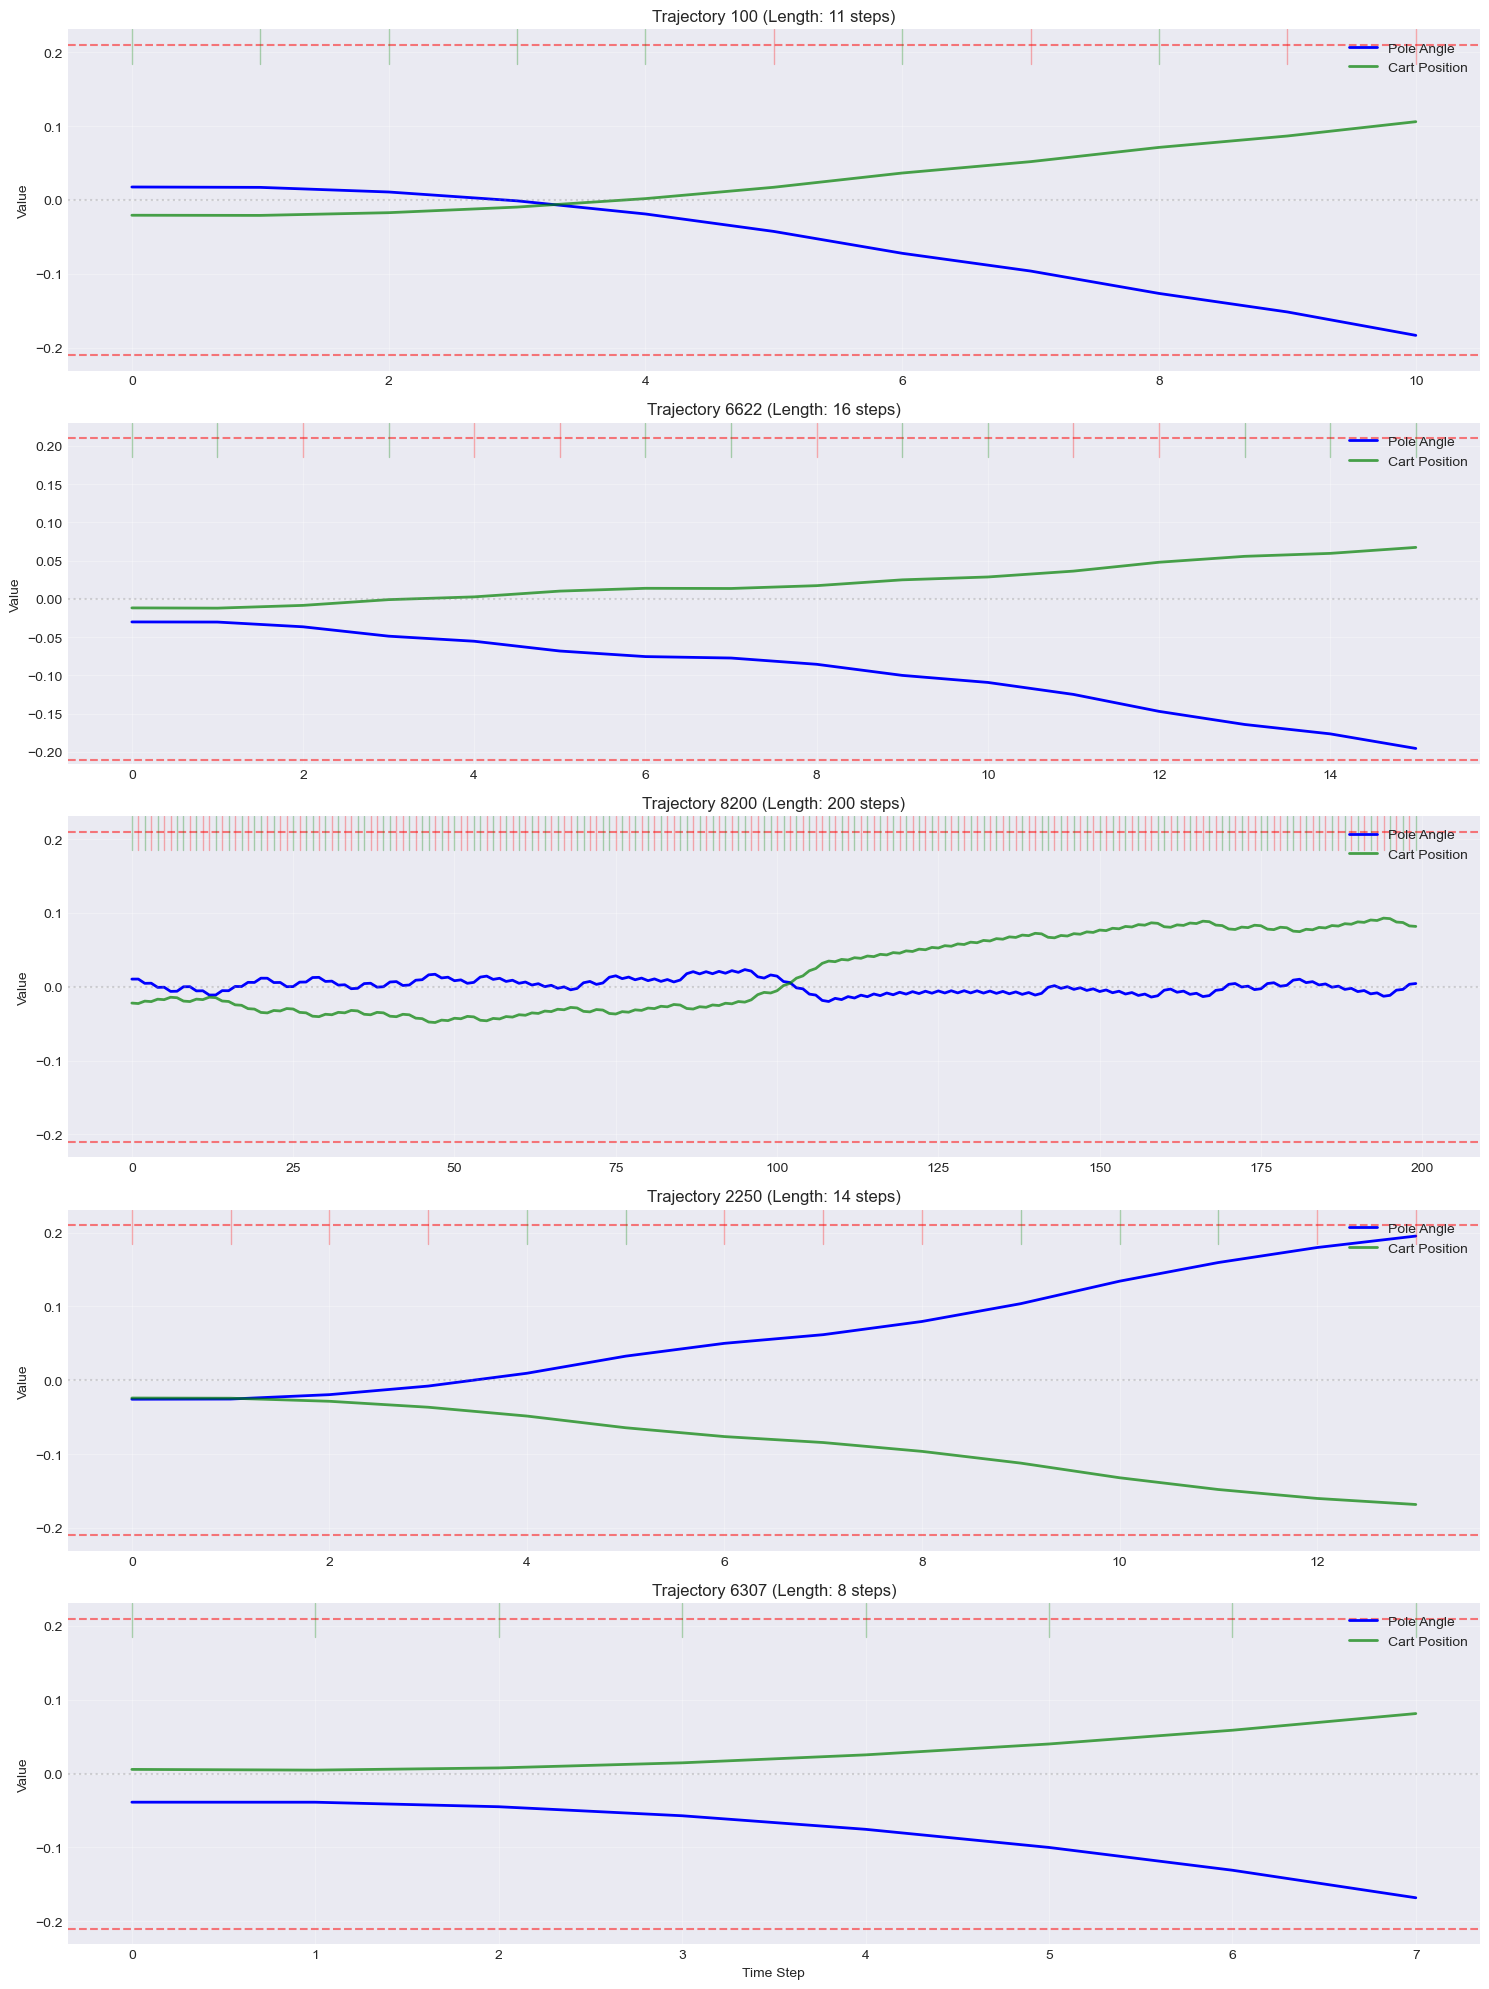

In [9]:
# Pick 5 random trajectories to visualize
import random

random_traj_ids = random.sample(df['trajectory_id'].unique().tolist(), 5)

fig, axes = plt.subplots(5, 1, figsize=(15, 20))

for idx, traj_id in enumerate(random_traj_ids):
    traj_data = df[df['trajectory_id'] == traj_id].sort_values('step')
    
    ax = axes[idx]
    steps = traj_data['step'].values
    pole_angle = traj_data['pole_angle'].values
    cart_pos = traj_data['cart_pos'].values
    
    # Plot pole angle
    ax.plot(steps, pole_angle, 'b-', label='Pole Angle', linewidth=2)
    ax.plot(steps, cart_pos, 'g-', label='Cart Position', linewidth=2, alpha=0.7)
    
    # Add fall threshold
    ax.axhline(y=0.21, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=-0.21, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
    
    # Mark actions
    for step, action in zip(steps, traj_data['action'].values):
        color = 'green' if action == 1 else 'red'
        ax.axvline(x=step, ymin=0.9, ymax=1, color=color, alpha=0.3, linewidth=1)
    
    traj_length = len(traj_data)
    ax.set_ylabel('Value')
    ax.set_title(f'Trajectory {traj_id} (Length: {traj_length} steps)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Step')
plt.tight_layout()
plt.show()

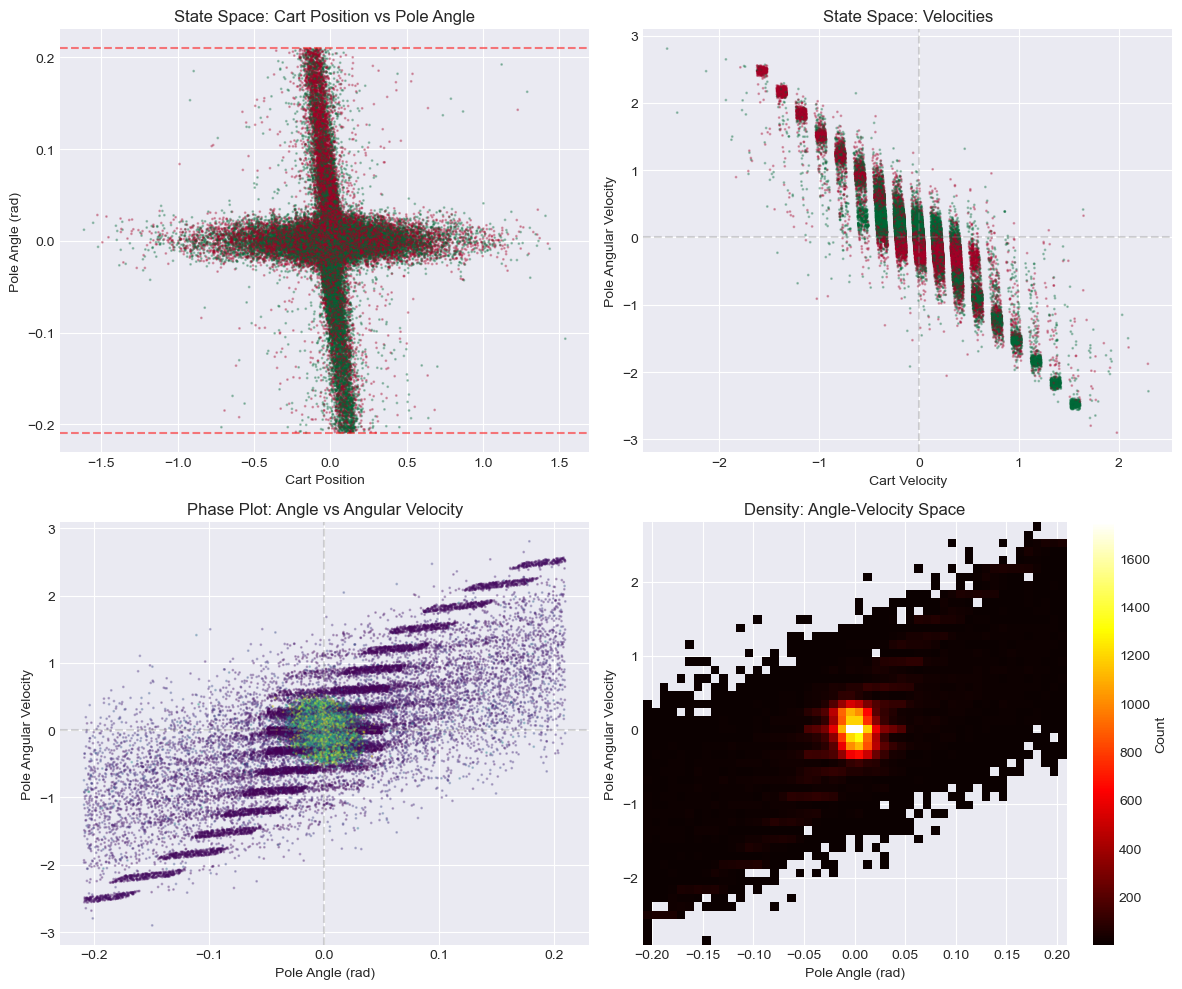

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sample 20% of data for faster plotting (if dataset is large)
sample_df = df.sample(min(50000, len(df))) if len(df) > 50000 else df

# 1. Position vs Angle
ax1 = axes[0, 0]
ax1.scatter(sample_df['cart_pos'], sample_df['pole_angle'], 
            c=sample_df['action'], cmap='RdYlGn', alpha=0.3, s=1)
ax1.set_xlabel('Cart Position')
ax1.set_ylabel('Pole Angle (rad)')
ax1.set_title('State Space: Cart Position vs Pole Angle')
ax1.axhline(y=0.21, color='r', linestyle='--', alpha=0.5)
ax1.axhline(y=-0.21, color='r', linestyle='--', alpha=0.5)

# 2. Velocity vs Angular Velocity
ax2 = axes[0, 1]
ax2.scatter(sample_df['cart_vel'], sample_df['pole_vel'], 
            c=sample_df['action'], cmap='RdYlGn', alpha=0.3, s=1)
ax2.set_xlabel('Cart Velocity')
ax2.set_ylabel('Pole Angular Velocity')
ax2.set_title('State Space: Velocities')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# 3. Angle vs Angular Velocity (phase plot)
ax3 = axes[1, 0]
ax3.scatter(sample_df['pole_angle'], sample_df['pole_vel'], 
            c=sample_df['step'], cmap='viridis', alpha=0.3, s=1)
ax3.set_xlabel('Pole Angle (rad)')
ax3.set_ylabel('Pole Angular Velocity')
ax3.set_title('Phase Plot: Angle vs Angular Velocity')
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

# 4. 2D histogram of angle space
ax4 = axes[1, 1]
h2d = ax4.hist2d(sample_df['pole_angle'], sample_df['pole_vel'], 
                  bins=50, cmap='hot', cmin=1)
ax4.set_xlabel('Pole Angle (rad)')
ax4.set_ylabel('Pole Angular Velocity')
ax4.set_title('Density: Angle-Velocity Space')
plt.colorbar(h2d[3], ax=ax4, label='Count')

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

state_cols = [
    "cart_pos",
    "cart_vel",
    "pole_angle",
    "pole_vel"
]

next_state_cols = [
    "next_cart_pos",
    "next_cart_vel",
    "next_pole_angle",
    "next_pole_vel"
]

# =========================================================
# SPLIT TRAJECTORIES, NOT INDIVIDUAL ROWS
# =========================================================

train_trajs, val_trajs = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42
)

# =========================================================
# FIT OBSERVATION SCALER ONLY ON TRAIN TRAJECTORIES
# =========================================================

train_obs_all = []

for traj in train_trajs:
    obs = traj.get_observations()
    train_obs_all.append(obs)

train_obs_all = np.concatenate(train_obs_all, axis=0)

obs_scaler = StandardScaler()
obs_scaler.fit(train_obs_all)

# =========================================================
# CREATE SEQUENCE WINDOWS
# =========================================================

SEQ_LEN = 20

def make_sequence_windows(trajectories, obs_scaler, seq_len):
    X_seq = []
    A_seq = []
    Y_seq = []

    for traj in trajectories:
        obs = traj.get_observations()              # [T, 4]
        next_obs = traj.get_next_observations()    # [T, 4]
        acts = traj.get_actions()                  # [T]

        T = len(acts)

        if T < seq_len:
            continue

        for start in range(T - seq_len + 1):
            x_window = obs[start : start + seq_len]
            a_window = acts[start : start + seq_len]
            y_window = next_obs[start : start + seq_len]

            if len(x_window) == seq_len and len(y_window) == seq_len:
                X_seq.append(x_window)
                A_seq.append(a_window)
                Y_seq.append(y_window)

    X_seq = np.stack(X_seq).astype(np.float32)
    A_seq = np.stack(A_seq).astype(np.float32)[..., None]
    Y_seq = np.stack(Y_seq).astype(np.float32)

    N, H, D = X_seq.shape

    X_seq_norm = obs_scaler.transform(
        X_seq.reshape(-1, D)
    ).reshape(N, H, D)

    Y_seq_norm = obs_scaler.transform(
        Y_seq.reshape(-1, D)
    ).reshape(N, H, D)

    return X_seq_norm, A_seq, Y_seq_norm

X_train_seq, A_train_seq, Y_train_seq = make_sequence_windows(
    train_trajs, obs_scaler, SEQ_LEN
)

X_val_seq, A_val_seq, Y_val_seq = make_sequence_windows(
    val_trajs, obs_scaler, SEQ_LEN
)

print("Train X seq:", X_train_seq.shape)
print("Train A seq:", A_train_seq.shape)
print("Train Y seq:", Y_train_seq.shape)

print("Val X seq:", X_val_seq.shape)
print("Val A seq:", A_val_seq.shape)
print("Val Y seq:", Y_val_seq.shape)

Train X seq: (161718, 20, 4)
Train A seq: (161718, 20, 1)
Train Y seq: (161718, 20, 4)
Val X seq: (45566, 20, 4)
Val A seq: (45566, 20, 1)
Val Y seq: (45566, 20, 4)


In [13]:
import torch

processed_data = {
    "X_train_seq": torch.tensor(X_train_seq, dtype=torch.float32),
    "A_train_seq": torch.tensor(A_train_seq, dtype=torch.float32),
    "Y_train_seq": torch.tensor(Y_train_seq, dtype=torch.float32),

    "X_val_seq": torch.tensor(X_val_seq, dtype=torch.float32),
    "A_val_seq": torch.tensor(A_val_seq, dtype=torch.float32),
    "Y_val_seq": torch.tensor(Y_val_seq, dtype=torch.float32),

    "obs_mean": torch.tensor(obs_scaler.mean_, dtype=torch.float32),
    "obs_std": torch.tensor(obs_scaler.scale_, dtype=torch.float32),

    "state_cols": state_cols,
    "next_state_cols": next_state_cols,

    "seq_len": SEQ_LEN,
    "input_dim": 4,
    "action_dim": 1,
}

torch.save(processed_data, "processed_cartpole_dynamics.pt")

print("Saved sequence dataset to processed_cartpole_dynamics.pt")

Saved sequence dataset to processed_cartpole_dynamics.pt
